In [1]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import seaborn as sns

### load the dataset

In [2]:
df_train = pd.read_csv("/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train.csv")
df_test = pd.read_csv("/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test.csv")

### basic Info

In [ ]:
df_train.shape

In [ ]:
df_train.info()

In [3]:
df_train.head()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [ ]:
df_train.describe()

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId
count,39209.000000,39209.000000,39209.000000,39209.000000,39209.000000,39209.000000,39209.000000
mean,50.835880,50.328930,5.999515,5.962381,45.197302,44.728379,15.788390
std,24.306933,23.115423,1.475493,1.385440,23.060157,21.971145,12.013238
min,25.000000,25.000000,0.000000,5.000000,20.000000,20.000000,0.000000
25%,35.000000,35.000000,5.000000,5.000000,29.000000,30.000000,5.000000
50%,43.000000,43.000000,6.000000,6.000000,38.000000,38.000000,12.000000
75%,58.000000,58.000000,6.000000,6.000000,53.000000,52.000000,25.000000
max,243.000000,225.000000,20.000000,20.000000,223.000000,205.000000,42.000000


### variable Distributions|

In [ ]:
sns.histplot(data = df_train, x = 'Width', kde = True)

In [ ]:
sns.histplot(data = df_train, x = 'Height', kde = True)

In [ ]:
ax = sns.countplot(data = df_train, x = 'ClassId')
ax.tick_params(axis='both', labelsize=6)
ax.set_xlabel('Category', fontsize=16)
ax.set_ylabel('Count', fontsize=16)

In [ ]:
value_count = df_train['ClassId'].value_counts() / len(df_train)
print(value_count.sort_values(ascending= False))

In [ ]:
plt.hist(df_train["Height"]*df_train["Width"], bins=100, edgecolor='black')
plt.title('Histogram Title')
plt.xlabel('Value Intervals')
plt.ylabel('Frequency')
plt.show()

### Load Images

In [ ]:
base_path = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"
def load_images(df, target_size=(32, 32)):
    images = []
    labels = []
    for idx in range(df.shape[0]):
        roi = df.iloc[idx,2:6]
        img_path = os.path.join(base_path,df.loc[idx,"Path"])
        with Image.open(img_path) as img:
            crop_box = (roi["Roi.X1"],roi["Roi.Y1"],roi["Roi.X2"],roi["Roi.Y2"])
            img = img.crop(crop_box)
            img = img.resize(target_size)
            images.append(img)
            labels.append(df.loc[idx,"ClassId"])
    return np.array(images), np.array(labels)


In [ ]:
X_train,y_train = load_images(df_train)
X_test,y_test = load_images(df_test)

### Sample Img per class

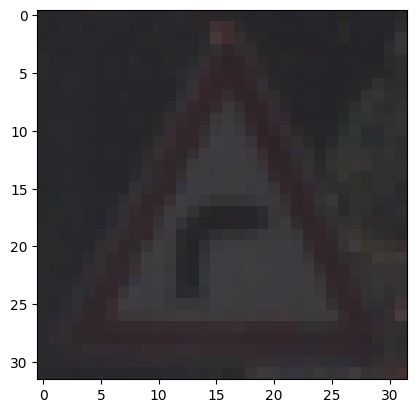

In [ ]:
fig, axes = plt.subplots(9, 5, figsize= (15, 20))
for i, ax in enumerate(axes.flatten()):
  if i > 42:
    ax.axis('off')
    continue
  img = X_train[y_train == i][0]
  ax.imshow(img)
  ax.set_title(f'Class {i}')
  ax.axis('off')

### Pixels stats

In [ ]:
def pixel_stats(X):

  flatten_img = X.flatten()
  Stats = {
      'mean': [np.mean(flatten_img)],
      'median': [np.median(flatten_img)],
      'std': [np.std(flatten_img)],
      'max': [np.max(flatten_img)],
      'min': [np.min(flatten_img)],
  }
  return pd.DataFrame(Stats)

In [ ]:
stats = pixel_stats(X_train)
stats = stats.T.rename(columns={0: 'value'})
print(stats)

In [ ]:
#Flattening
images = X_train.reshape(X_train.shape[0], -1)
labels = y_train
images = images / 255
scaler = StandardScaler()
images_scaled = scaler.fit_transform(images)

In [ ]:
#PCA implementation
pca = PCA(n_components=100)
image_pca = pca.fit_transform(images_scaled)
print(image_pca.shape)

#LDA implementation
lda = LDA(n_components=2)
image_lda = lda.fit_transform(image_pca, labels)
print(image_lda.shape)

In [ ]:
#Plot 1 : PCA explained variance
plt.figure(figsize=(10,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title('PCA Explained Variance')
plt.xlabel('Components (features)')
plt.ylabel('Cumulative Variance')
plt.show()

#Plot 2 : LDA 2D Scatter Plot
plt.figure(figsize=(10,8))
plt.scatter(image_lda[:,0], image_lda[:,1], c=labels, cmap='tab20', alpha=0.3, s=1)
plt.title('LDA 2D Scatter Plot')
plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')
plt.colorbar(label='Traffic Sign Class')
plt.show()


#Plot 3 : PCA 2D Scatter Plot
plt.figure(figsize=(10,8))
plt.scatter(image_pca[:,0], image_pca[:,1], c=labels, cmap='tab20', alpha=0.3, s=1)
plt.title('PCA 2D Scatter Plot')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Traffic Sign Class')
plt.show()